# Lab 04 - Decision Tree Learning

## Aim
## To implement Decision Tree classification using Python and Scikit-learn on the given datasets.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Part A: Decision Tree Using Weather Dataset

In [55]:
weather = pd.read_csv("weather.csv")

print("Weather Dataset:")
print(weather.head())

Weather Dataset:
    outlook temperature humidity  windy play
0     sunny         hot     high  False   no
1     sunny         hot     high   True   no
2  overcast         hot     high  False  yes
3     rainy        mild     high  False  yes
4     rainy        cool   normal  False  yes


## Dataset Information

In [56]:
print("Dataset Shape:")
print(weather.shape)

print("\nColumn Names:")
print(weather.columns)

print("\nDataset Information:")
print(weather.info())

print("\nMissing Values:")
print(weather.isnull().sum())

Dataset Shape:
(14, 5)

Column Names:
Index(['outlook', 'temperature', 'humidity', 'windy', 'play'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   outlook      14 non-null     object
 1   temperature  14 non-null     object
 2   humidity     14 non-null     object
 3   windy        14 non-null     bool  
 4   play         14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes
None

Missing Values:
outlook        0
temperature    0
humidity       0
windy          0
play           0
dtype: int64


## Exploring the Weather Dataset

In [57]:
print(weather.describe(include='all'))

       outlook temperature humidity  windy play
count       14          14       14     14   14
unique       3           3        2      2    2
top      sunny        mild     high  False  yes
freq         5           6        7      8    9


## Data Preprocessing

In [58]:
# Create a copy of the dataset
weather_encoded = weather.copy()

# Encode categorical columns
label_encoders = {}

for column in weather_encoded.columns:
    le = LabelEncoder()
    weather_encoded[column] = le.fit_transform(weather_encoded[column])
    label_encoders[column] = le

print("Encoded Weather Dataset:")
print(weather_encoded.head())

Encoded Weather Dataset:
   outlook  temperature  humidity  windy  play
0        2            1         0      0     0
1        2            1         0      1     0
2        0            1         0      0     1
3        1            2         0      0     1
4        1            0         1      0     1


## Splitting Features and Target

In [59]:
# Separate input features and target variable

X = weather_encoded.drop("play", axis=1)
y = weather_encoded["play"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   outlook  temperature  humidity  windy
0        2            1         0      0
1        2            1         0      1
2        0            1         0      0
3        1            2         0      0
4        1            0         1      0

Target (y):
0    0
1    0
2    1
3    1
4    1
Name: play, dtype: int64


## Splitting Training and Testing Data

In [60]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (11, 4)
Testing data shape: (3, 4)


## Training the Decision Tree Model

In [61]:
# Create and train the Decision Tree model

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


## Making Predictions

In [62]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[1 1 0]

Predicted Values:
[1 1 0]


## Model Evaluation

In [63]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


## Classification Report and Confusion Matrix

In [64]:
# Classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Confusion Matrix:
[[1 0]
 [0 2]]


## Visualizing the Decision Tree

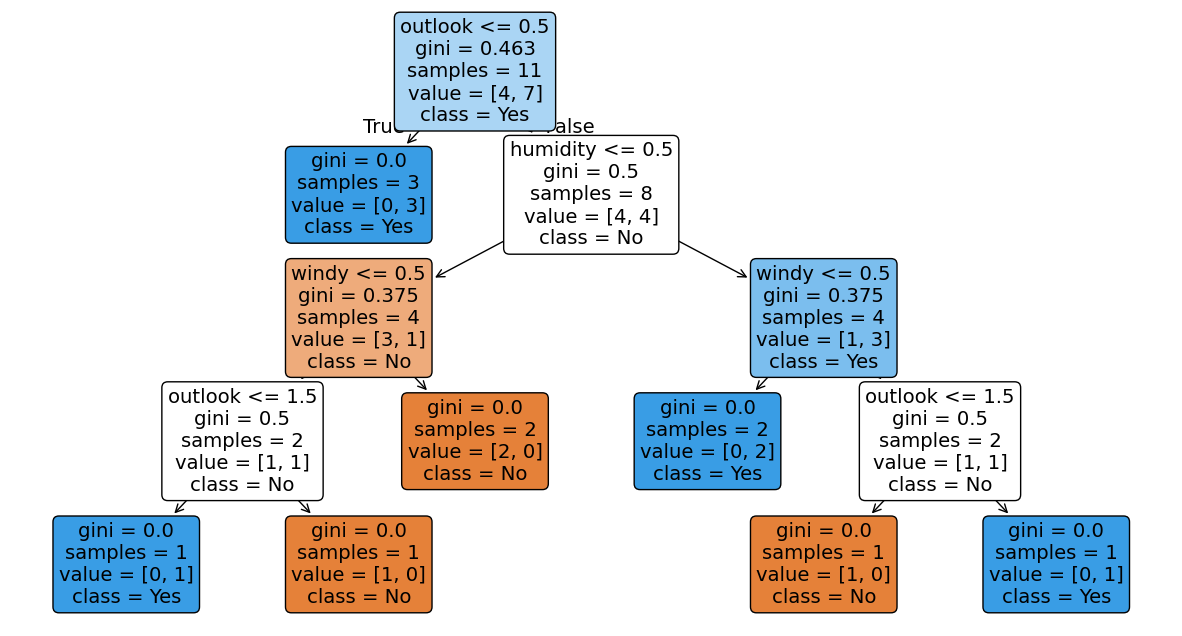

In [65]:
# Visualize the Decision Tree

plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)

plt.show()

## Part B: Decision Tree Using Calorie Efficiency **Dataset**



## 1. Importing Required Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Loading the Calorie Efficiency Dataset

In [67]:
calorie = pd.read_csv("calorie_efficiency_dataset.csv")

print("Calorie Efficiency Dataset:")
print(calorie.head())

Calorie Efficiency Dataset:
   age  steps_per_day  active_minutes  calories_burned  sleep_hours  \
0   51           7853              99             1500         6.42   
1   60           4820              78             1500         6.82   
2   59           4251              28             1500         6.99   
3   39           6275              75             1500         6.65   
4   22           6490              82             1500         5.80   

   hydration_liters    bmi  workouts_per_week  muscle_mass_ratio  \
0              3.60  22.34                  3              0.321   
1              4.18  32.30                  6              0.548   
2              2.95  24.71                  2              0.245   
3              2.62  28.80                  1              0.389   
4              0.97  21.92                  2              0.326   

   body_fat_percentage  heart_rate_resting  heart_rate_avg  \
0                0.050                68.5           102.0   
1           

## 3. Dataset Information

In [68]:
print("Dataset Shape:")
print(calorie.shape)

print("\nColumn Names:")
print(calorie.columns)

print("\nDataset Information:")
print(calorie.info())

print("\nMissing Values:")
print(calorie.isnull().sum())

Dataset Shape:
(1000000, 15)

Column Names:
Index(['age', 'steps_per_day', 'active_minutes', 'calories_burned',
       'sleep_hours', 'hydration_liters', 'bmi', 'workouts_per_week',
       'muscle_mass_ratio', 'body_fat_percentage', 'heart_rate_resting',
       'heart_rate_avg', 'continuous_exercise_days', 'efficiency_score',
       'calorie_efficiency'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   steps_per_day             1000000 non-null  int64  
 2   active_minutes            1000000 non-null  int64  
 3   calories_burned           1000000 non-null  int64  
 4   sleep_hours               1000000 non-null  float64
 5   hydration_liters          1000000 non-null  float64
 6   bmi                      

## 4. Exploring the Calorie Efficiency Dataset

In [69]:
print(calorie.describe(include="all"))

                   age   steps_per_day  active_minutes  calories_burned  \
count   1000000.000000  1000000.000000  1000000.000000        1000000.0   
unique             NaN             NaN             NaN              NaN   
top                NaN             NaN             NaN              NaN   
freq               NaN             NaN             NaN              NaN   
mean         40.982084     7001.232915       69.673644           1500.0   
std          13.550471     2482.813116       28.602711              0.0   
min          18.000000     1000.000000       10.000000           1500.0   
25%          29.000000     5309.000000       50.000000           1500.0   
50%          41.000000     6993.000000       69.000000           1500.0   
75%          53.000000     8683.000000       89.000000           1500.0   
max          64.000000    18924.000000      180.000000           1500.0   

           sleep_hours  hydration_liters             bmi  workouts_per_week  \
count   1000000.0000

## 5. Data Preprocessing

In [70]:
calorie_encoded = calorie.copy()

label_encoders = {}

for column in calorie_encoded.columns:
    if calorie_encoded[column].dtype == "object":
        le = LabelEncoder()
        calorie_encoded[column] = le.fit_transform(calorie_encoded[column])
        label_encoders[column] = le

print("Encoded Dataset:")
print(calorie_encoded.head())

Encoded Dataset:
   age  steps_per_day  active_minutes  calories_burned  sleep_hours  \
0   51           7853              99             1500         6.42   
1   60           4820              78             1500         6.82   
2   59           4251              28             1500         6.99   
3   39           6275              75             1500         6.65   
4   22           6490              82             1500         5.80   

   hydration_liters    bmi  workouts_per_week  muscle_mass_ratio  \
0              3.60  22.34                  3              0.321   
1              4.18  32.30                  6              0.548   
2              2.95  24.71                  2              0.245   
3              2.62  28.80                  1              0.389   
4              0.97  21.92                  2              0.326   

   body_fat_percentage  heart_rate_resting  heart_rate_avg  \
0                0.050                68.5           102.0   
1                0.200 

## 6. Splitting Features and Target

In [78]:
X = calorie_encoded.drop("calorie_efficiency", axis=1)

y = calorie_encoded["calorie_efficiency"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   age  steps_per_day  active_minutes  calories_burned  sleep_hours  \
0   51           7853              99             1500         6.42   
1   60           4820              78             1500         6.82   
2   59           4251              28             1500         6.99   
3   39           6275              75             1500         6.65   
4   22           6490              82             1500         5.80   

   hydration_liters    bmi  workouts_per_week  muscle_mass_ratio  \
0              3.60  22.34                  3              0.321   
1              4.18  32.30                  6              0.548   
2              2.95  24.71                  2              0.245   
3              2.62  28.80                  1              0.389   
4              0.97  21.92                  2              0.326   

   body_fat_percentage  heart_rate_resting  heart_rate_avg  \
0                0.050                68.5           102.0   
1                0.200    

## 7. Splitting Training and Testing Data

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (800000, 14)
Testing Data Shape: (200000, 14)


## 8. Training the Decision Tree Model

In [80]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


## 9. Making Predictions

In [81]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values[:20])

print("\nPredicted Values:")
print(y_pred[:20])

Actual Values:
[1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1]

Predicted Values:
[1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 2 2 1 0]


## 10. Model Evaluation

In [82]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.88091


## 11. Classification Report and Confusion Matrix


In [83]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

High Efficiency       0.03      0.04      0.03      5481
 Low Efficiency       0.95      0.93      0.94    187551
       Moderate       0.20      0.25      0.22      6968

       accuracy                           0.88    200000
      macro avg       0.39      0.41      0.40    200000
   weighted avg       0.89      0.88      0.89    200000


Confusion Matrix:
[[   210   5043    228]
 [  6629 174226   6696]
 [   250   4972   1746]]


## 12. Visualizing the Decision Tree

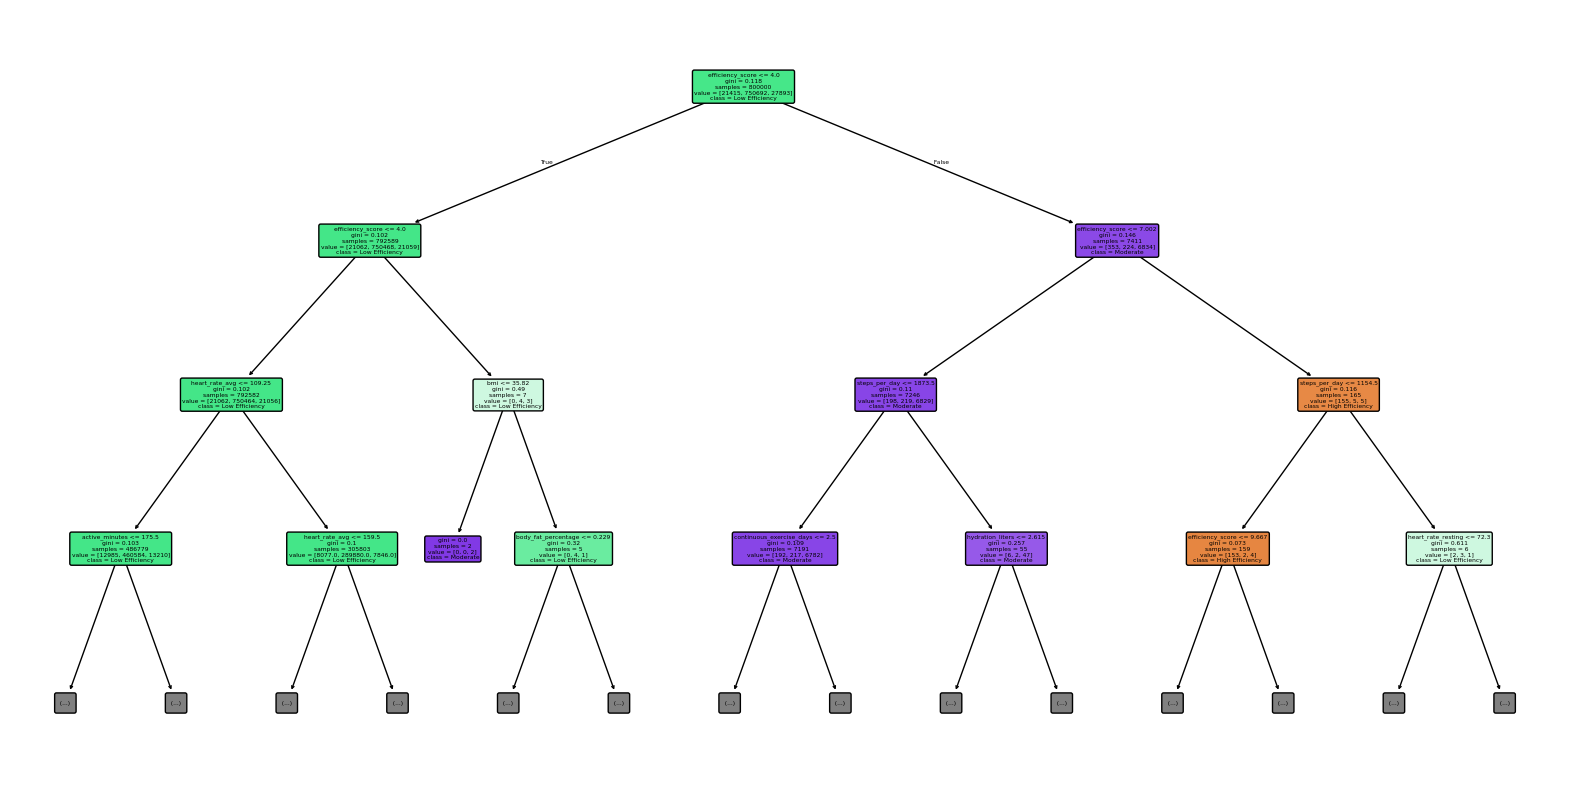

In [84]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()